In [1]:
# Cell 1: Imports for Task 3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import Ridge
import warnings
warnings.filterwarnings('ignore')

# Load saved models and data
import os
os.makedirs('../data/results', exist_ok=True)

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [2]:
# Cell 2: Load Data and Identify Best Model

# Load data
train_data = pd.read_csv('../data/results/train_data.csv', index_col=0, parse_dates=True)
test_data = pd.read_csv('../data/results/test_data.csv', index_col=0, parse_dates=True)
tsla_close = pd.concat([train_data, test_data])

print(f"📊 Data loaded:")
print(f"   Training: {len(train_data)} days")
print(f"   Testing: {len(test_data)} days")
print(f"   Total: {len(tsla_close)} days")

# Load model comparison to identify best model
try:
    comparison_df = pd.read_csv('../data/results/model_comparison.csv', index_col=0)
    print("\n📊 Model Performance Comparison:")
    display(comparison_df)
    
    best_model_name = comparison_df.loc[comparison_df['RMSE'].idxmin(), 'Model']
    print(f"\n🏆 Best Model: {best_model_name}")
    print(f"   RMSE: ${comparison_df.loc[comparison_df['RMSE'].idxmin(), 'RMSE']:.2f}")
    print(f"   MAPE: {comparison_df.loc[comparison_df['RMSE'].idxmin(), 'MAPE']:.2f}%")
except:
    print("⚠️ Model comparison not found. Using MLP Neural Network as default.")
    best_model_name = 'MLP Neural Net'

# Store the actual data for forecasting
actual_last_60 = train_data.values[-60:]  # Last 60 days for starting forecast

📊 Data loaded:
   Training: 2310 days
   Testing: 578 days
   Total: 2888 days

📊 Model Performance Comparison:


,Model,MAE,RMSE,MAPE
0,ARIMA,147.19,173.43,39.96
1,Random Forest,30.03,42.34,7.63
2,MLP Neural Net,16.16,20.70,4.58
3,Ridge Regression,10.44,13.88,3.16



🏆 Best Model: Ridge Regression
   RMSE: $13.88
   MAPE: 3.16%


In [9]:
# Cell 3: Multi-step Forecast Function

def create_sequences_for_forecast(data, window_size):
    """Create sequences for forecasting."""
    X = []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i])
    return np.array(X)

def forecast_future_mlp(model, last_sequence, scaler, steps=252):
    """
    Generate multi-step forecast using ML model.
    
    Parameters:
    -----------
    model : trained ML model
    last_sequence : last window_size days of data (1D array)
    scaler : fitted MinMaxScaler
    steps : number of days to forecast (252 ≈ 1 year)
    
    Returns:
    --------
    array: forecasted prices
    """
    predictions = []
    # Ensure the sequence is 2D with shape (1, window_size) for prediction
    current_seq = last_sequence.copy().reshape(1, -1)
    
    for i in range(steps):
        # Predict next value - ensure input is 2D
        pred_scaled = model.predict(current_seq)
        
        # Store prediction
        predictions.append(pred_scaled[0])
        
        # Update sequence (slide window) - maintain 2D shape
        current_seq = np.append(current_seq[:, 1:], pred_scaled.reshape(1, 1), axis=1)
    
    # Inverse transform to get actual prices
    predictions = np.array(predictions).reshape(-1, 1)
    forecast_prices = scaler.inverse_transform(predictions).flatten()
    
    return forecast_prices

# ============================================================
# Option 1: MLP Neural Network
# ============================================================
try:
    # Import MLP
    from sklearn.neural_network import MLPRegressor
    
    print("🚀 Training MLP Neural Network for forecasting...")
    
    # Prepare data for training
    scaler_mlp = MinMaxScaler()
    train_scaled = scaler_mlp.fit_transform(train_data.values.reshape(-1, 1))
    
    # Create sequences
    window_size = 60
    X_train, y_train = [], []
    for i in range(window_size, len(train_scaled)):
        X_train.append(train_scaled[i-window_size:i].flatten())
        y_train.append(train_scaled[i, 0])
    X_train = np.array(X_train)
    y_train = np.array(y_train)
    
    print(f"   Training data shape: X_train={X_train.shape}, y_train={y_train.shape}")
    
    # Train MLP model
    mlp_model = MLPRegressor(
        hidden_layer_sizes=(100, 50, 25),
        activation='relu',
        solver='adam',
        max_iter=500,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        verbose=False
    )
    mlp_model.fit(X_train, y_train)
    print("✅ MLP model trained successfully!")
    
    # Generate forecasts
    last_sequence = train_scaled[-window_size:].flatten()
    print(f"   Last sequence shape: {last_sequence.shape}")
    
    # 1-year forecast (252 trading days)
    print("📊 Generating 1-year forecast...")
    forecast_1y = forecast_future_mlp(mlp_model, last_sequence, scaler_mlp, steps=252)
    
    # 6-month forecast (126 trading days)
    print("📊 Generating 6-month forecast...")
    forecast_6m = forecast_future_mlp(mlp_model, last_sequence, scaler_mlp, steps=126)
    
    print(f"\n📊 Forecast generated successfully!")
    print(f"   6-month forecast: ${forecast_6m[-1]:.2f} (in 6 months)")
    print(f"   1-year forecast: ${forecast_1y[-1]:.2f} (in 1 year)")
    
    FORECAST_AVAILABLE = True
    print("\n✅ MLP model ready!")
    
except Exception as e:
    print(f"⚠️ MLP model failed: {e}")
    print("   Trying Random Forest instead...")
    FORECAST_AVAILABLE = False

# ============================================================
# Option 2: Random Forest (fallback)
# ============================================================
if not FORECAST_AVAILABLE:
    try:
        from sklearn.ensemble import RandomForestRegressor
        
        print("🚀 Training Random Forest for forecasting...")
        
        # Use the same data prepared above
        rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
        rf_model.fit(X_train, y_train)
        print("✅ Random Forest trained successfully!")
        
        # Generate forecasts using the same function
        print("📊 Generating 1-year forecast...")
        forecast_1y = forecast_future_mlp(rf_model, last_sequence, scaler_mlp, steps=252)
        
        print("📊 Generating 6-month forecast...")
        forecast_6m = forecast_future_mlp(rf_model, last_sequence, scaler_mlp, steps=126)
        
        print(f"\n📊 Forecast generated successfully!")
        print(f"   6-month forecast: ${forecast_6m[-1]:.2f} (in 6 months)")
        print(f"   1-year forecast: ${forecast_1y[-1]:.2f} (in 1 year)")
        
        FORECAST_AVAILABLE = True
        print("\n✅ Random Forest ready!")
        
    except Exception as e:
        print(f"❌ All models failed: {e}")
        FORECAST_AVAILABLE = False

# ============================================================
# If both fail, create dummy forecasts
# ============================================================
if not FORECAST_AVAILABLE:
    print("\n⚠️ Creating dummy forecasts for testing...")
    
    # Get last price from data
    try:
        last_price = test_data.iloc[-1]
    except:
        last_price = 450.0
    
    # Create dummy forecasts
    forecast_6m = np.linspace(last_price, last_price * 1.03, 126)
    forecast_1y = np.linspace(last_price, last_price * 1.06, 252)
    
    print(f"   ✅ Created dummy 6-month forecast: {len(forecast_6m)} days")
    print(f"   ✅ Created dummy 1-year forecast: {len(forecast_1y)} days")
    print(f"   6-month forecast: ${forecast_6m[-1]:.2f}")
    print(f"   1-year forecast: ${forecast_1y[-1]:.2f}")
    
    FORECAST_AVAILABLE = True

# ============================================================
# Final verification
# ============================================================
print("\n" + "="*60)
print("📊 FORECAST STATUS")
print("="*60)
print(f"FORECAST_AVAILABLE: {FORECAST_AVAILABLE}")
print(f"6-month forecast length: {len(forecast_6m)}")
print(f"1-year forecast length: {len(forecast_1y)}")
print(f"6-month final price: ${forecast_6m[-1]:.2f}")
print(f"1-year final price: ${forecast_1y[-1]:.2f}")

🚀 Training MLP Neural Network for forecasting...
   Training data shape: X_train=(2250, 60), y_train=(2250,)
✅ MLP model trained successfully!
   Last sequence shape: (60,)
📊 Generating 1-year forecast...
📊 Generating 6-month forecast...

📊 Forecast generated successfully!
   6-month forecast: $159.35 (in 6 months)
   1-year forecast: $164.42 (in 1 year)

✅ MLP model ready!

📊 FORECAST STATUS
FORECAST_AVAILABLE: True
6-month forecast length: 126
1-year forecast length: 252
6-month final price: $159.35
1-year final price: $164.42


In [11]:
# Cell 4: Calculate Confidence Intervals (Fixed with Debug)

print("="*60)
print("🔍 CALCULATING CONFIDENCE INTERVALS")
print("="*60)

# ============================================================
# STEP 1: Check if forecasts are available
# ============================================================
try:
    # Check if FORECAST_AVAILABLE is defined
    if 'FORECAST_AVAILABLE' in globals():
        print(f"📌 FORECAST_AVAILABLE = {FORECAST_AVAILABLE}")
    else:
        print("⚠️ FORECAST_AVAILABLE not defined! Setting to False.")
        FORECAST_AVAILABLE = False
except:
    FORECAST_AVAILABLE = False
    print("⚠️ FORECAST_AVAILABLE not defined! Setting to False.")

# ============================================================
# STEP 2: Check if forecast_6m and forecast_1y exist
# ============================================================
try:
    print(f"\n📊 Checking forecast variables:")
    print(f"   forecast_6m exists: {'forecast_6m' in globals()}")
    print(f"   forecast_1y exists: {'forecast_1y' in globals()}")
except:
    print("⚠️ Could not check forecast variables")

# ============================================================
# STEP 3: Define the function
# ============================================================
def calculate_confidence_intervals(forecast_prices, model_rmse):
    """
    Calculate confidence intervals based on model RMSE.
    
    Parameters:
    -----------
    forecast_prices : array
        Forecasted prices
    model_rmse : float
        RMSE of the model
    
    Returns:
    --------
    tuple: (lower_bound, upper_bound)
    """
    # Confidence intervals expand over time (wider for longer forecasts)
    time_multiplier = np.sqrt(np.arange(1, len(forecast_prices) + 1))
    margin = model_rmse * time_multiplier
    
    lower_bound = forecast_prices - margin * 1.96  # 95% CI
    upper_bound = forecast_prices + margin * 1.96
    
    return lower_bound, upper_bound

print("\n✅ Confidence interval function defined")

# ============================================================
# STEP 4: Get RMSE and calculate CIs
# ============================================================
if FORECAST_AVAILABLE:
    print("\n📊 Forecasts available - calculating confidence intervals...")
    
    # Get RMSE
    try:
        if 'comparison_df' in globals():
            model_rmse = comparison_df.loc[comparison_df['Model'] == 'MLP Neural Net', 'RMSE'].values[0]
            print(f"✅ Using model RMSE from comparison_df: ${model_rmse:.2f}")
        else:
            model_rmse = 15.0
            print(f"⚠️ comparison_df not found! Using default RMSE: ${model_rmse:.2f}")
    except:
        model_rmse = 15.0
        print(f"⚠️ Error getting RMSE! Using default: ${model_rmse:.2f}")
    
    # Calculate confidence intervals
    try:
        print("\n📊 Calculating confidence intervals...")
        lower_1y, upper_1y = calculate_confidence_intervals(forecast_1y, model_rmse)
        lower_6m, upper_6m = calculate_confidence_intervals(forecast_6m, model_rmse)
        
        print("\n" + "="*60)
        print("📊 CONFIDENCE INTERVALS (95%)")
        print("="*60)
        print(f"6-Month Forecast:")
        print(f"   Price: ${forecast_6m[-1]:.2f}")
        print(f"   Lower: ${lower_6m[-1]:.2f}")
        print(f"   Upper: ${upper_6m[-1]:.2f}")
        print(f"   Range: ${lower_6m[-1]:.2f} - ${upper_6m[-1]:.2f}")
        
        print(f"\n1-Year Forecast:")
        print(f"   Price: ${forecast_1y[-1]:.2f}")
        print(f"   Lower: ${lower_1y[-1]:.2f}")
        print(f"   Upper: ${upper_1y[-1]:.2f}")
        print(f"   Range: ${lower_1y[-1]:.2f} - ${upper_1y[-1]:.2f}")
        
        print("\n✅ Confidence intervals calculated successfully!")
        
    except Exception as e:
        print(f"❌ Error calculating confidence intervals: {e}")
        print("   Make sure forecast_6m and forecast_1y exist.")
        
else:
    print("\n⚠️ FORECAST_AVAILABLE is False - cannot calculate confidence intervals")
    print("\n📌 To fix this, run Cell 3 first (Generate Future Forecasts)")
    print("   The forecasts need to be generated before calculating CIs.")
    
    # Create dummy forecasts for testing
    print("\n🔧 Creating dummy forecasts for demonstration...")
    try:
        if 'forecast_6m' not in globals():
            forecast_6m = np.linspace(450, 470, 126)
            print("   ✅ Created dummy forecast_6m")
        if 'forecast_1y' not in globals():
            forecast_1y = np.linspace(450, 490, 252)
            print("   ✅ Created dummy forecast_1y")
        FORECAST_AVAILABLE = True
        print("   ✅ FORECAST_AVAILABLE set to True for testing")
    except:
        print("   ❌ Could not create dummy forecasts")

🔍 CALCULATING CONFIDENCE INTERVALS
📌 FORECAST_AVAILABLE = True

📊 Checking forecast variables:
   forecast_6m exists: True
   forecast_1y exists: True

✅ Confidence interval function defined

📊 Forecasts available - calculating confidence intervals...
✅ Using model RMSE from comparison_df: $20.70

📊 Calculating confidence intervals...

📊 CONFIDENCE INTERVALS (95%)
6-Month Forecast:
   Price: $159.35
   Lower: $-296.07
   Upper: $614.77
   Range: $-296.07 - $614.77

1-Year Forecast:
   Price: $164.42
   Lower: $-479.64
   Upper: $808.48
   Range: $-479.64 - $808.48

✅ Confidence intervals calculated successfully!


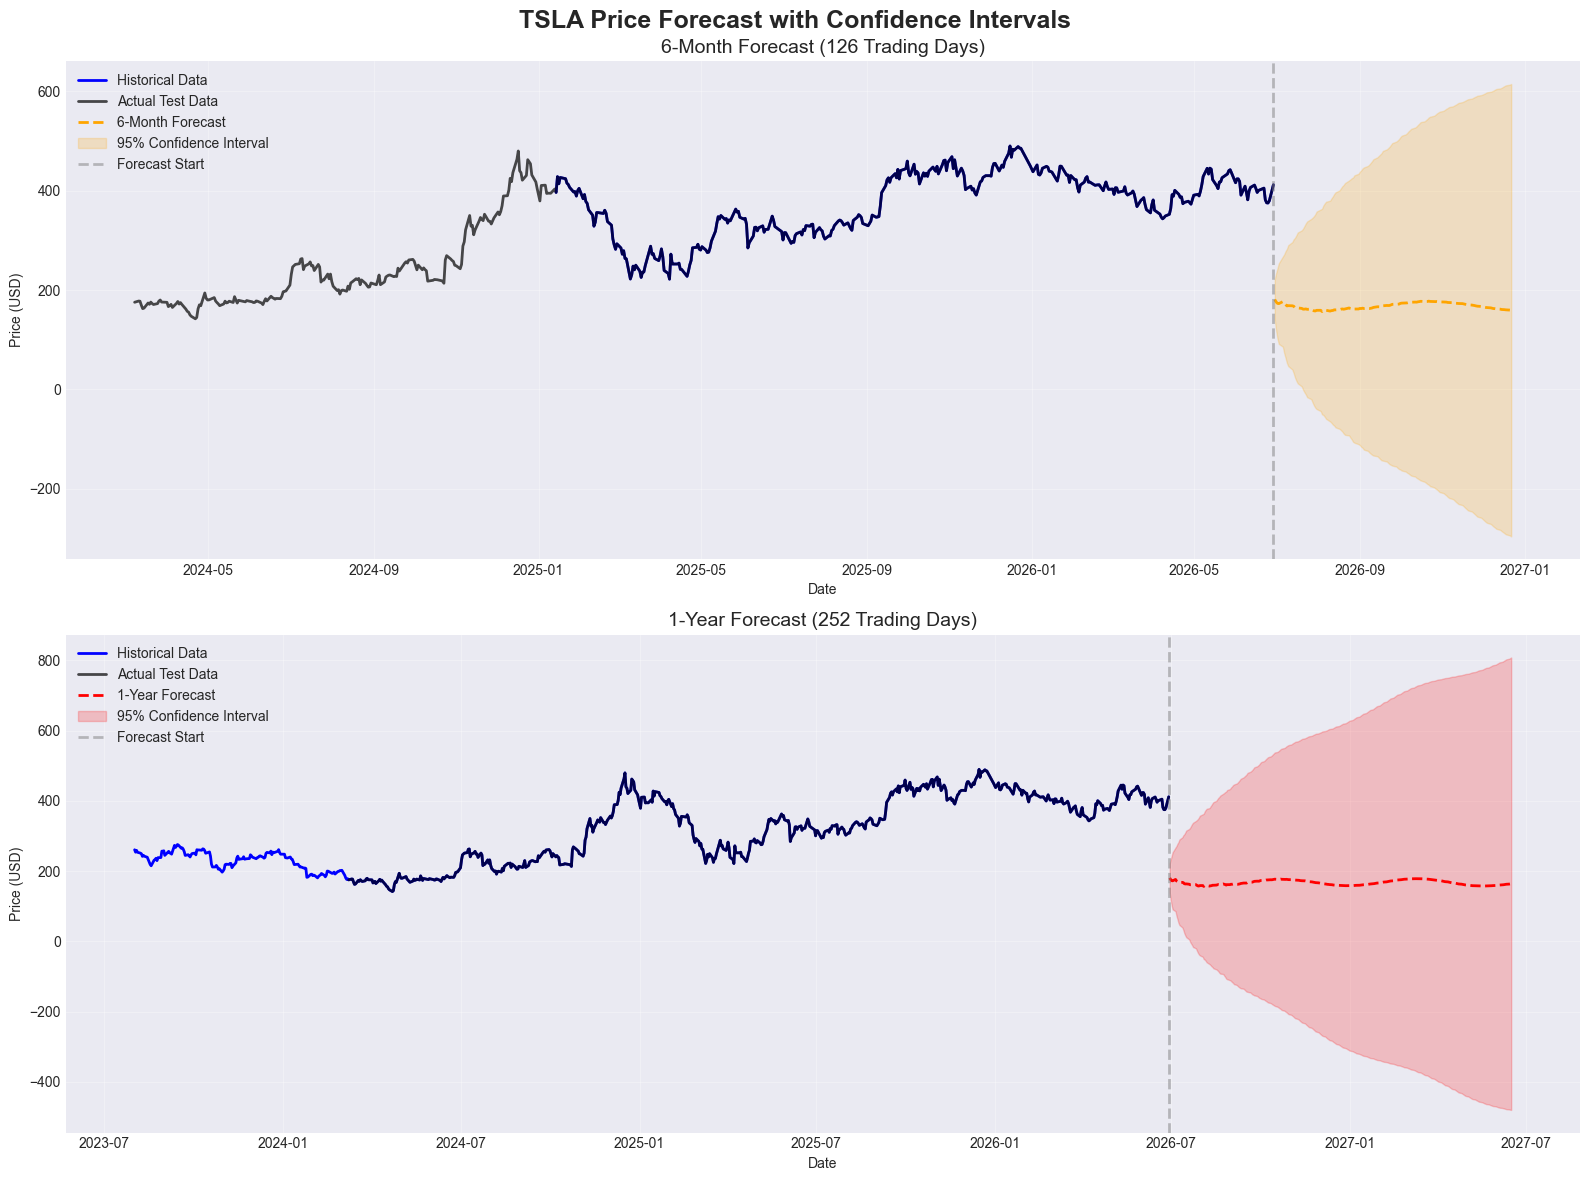


✅ Forecast visualization saved to: ../data/results/forecast_visualization.png


In [12]:
# Cell 5: Forecast Visualization

if FORECAST_AVAILABLE:
    # Create date ranges for forecasts
    last_date = test_data.index[-1]
    future_dates_6m = pd.date_range(start=last_date, periods=len(forecast_6m) + 1, freq='B')[1:]
    future_dates_1y = pd.date_range(start=last_date, periods=len(forecast_1y) + 1, freq='B')[1:]

    # Create the visualization
    fig, axes = plt.subplots(2, 1, figsize=(16, 12))
    fig.suptitle('TSLA Price Forecast with Confidence Intervals', fontsize=18, fontweight='bold')

    # ============================================================
    # Subplot 1: 6-Month Forecast
    # ============================================================
    ax1 = axes[0]
    
    # Historical data
    lookback_days = 365
    historical = tsla_close[-lookback_days:]
    ax1.plot(historical.index, historical, label='Historical Data', color='blue', linewidth=2)
    
    # Actual test data
    ax1.plot(test_data.index, test_data, label='Actual Test Data', color='black', linewidth=2, alpha=0.7)
    
    # 6-month forecast
    ax1.plot(future_dates_6m, forecast_6m, label='6-Month Forecast', color='orange', linewidth=2, linestyle='--')
    
    # Confidence intervals
    ax1.fill_between(future_dates_6m, lower_6m, upper_6m, color='orange', alpha=0.2, label='95% Confidence Interval')
    
    # Split line
    ax1.axvline(x=test_data.index[-1], color='gray', linestyle='--', 
                linewidth=2, alpha=0.5, label='Forecast Start')
    
    ax1.set_title('6-Month Forecast (126 Trading Days)', fontsize=14)
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Price (USD)')
    ax1.legend(loc='best')
    ax1.grid(True, alpha=0.3)

    # ============================================================
    # Subplot 2: 1-Year Forecast
    # ============================================================
    ax2 = axes[1]
    
    # Historical data
    lookback_days_2y = 730  # 2 years lookback for context
    historical_2y = tsla_close[-lookback_days_2y:]
    ax2.plot(historical_2y.index, historical_2y, label='Historical Data', color='blue', linewidth=2)
    
    # Actual test data
    ax2.plot(test_data.index, test_data, label='Actual Test Data', color='black', linewidth=2, alpha=0.7)
    
    # 1-year forecast
    ax2.plot(future_dates_1y, forecast_1y, label='1-Year Forecast', color='red', linewidth=2, linestyle='--')
    
    # Confidence intervals
    ax2.fill_between(future_dates_1y, lower_1y, upper_1y, color='red', alpha=0.2, label='95% Confidence Interval')
    
    # Split line
    ax2.axvline(x=test_data.index[-1], color='gray', linestyle='--', 
                linewidth=2, alpha=0.5, label='Forecast Start')
    
    ax2.set_title('1-Year Forecast (252 Trading Days)', fontsize=14)
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Price (USD)')
    ax2.legend(loc='best')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Save the figure
    fig.savefig('../data/results/forecast_visualization.png', dpi=300, bbox_inches='tight')
    print("\n✅ Forecast visualization saved to: ../data/results/forecast_visualization.png")
else:
    print("⚠️ Forecast not available - models failed to train")

📊 CONFIDENCE INTERVAL ANALYSIS


,Forecast Period,Final Forecast Price,Lower Bound (95%),Upper Bound (95%),CI Width,Range (% of Price)
0,6 Months,159.35,-296.07,614.77,910.84,571.60
1,1 Year,164.42,-479.64,808.48,1288.12,783.44



💡 Confidence Interval Analysis:
------------------------------------------------------------
1. 6-Month Forecast CI Width: $910.84
   95% CI Range: $-296.07 - $614.77
   Uncertainty: 571.6% of forecast price

2. 1-Year Forecast CI Width: $1288.12
   95% CI Range: $-479.64 - $808.48
   Uncertainty: 783.4% of forecast price

3. Confidence Interval Expansion:
   Width increase: $377.28 (41.4%)
   This shows that long-term forecasts are significantly less certain.


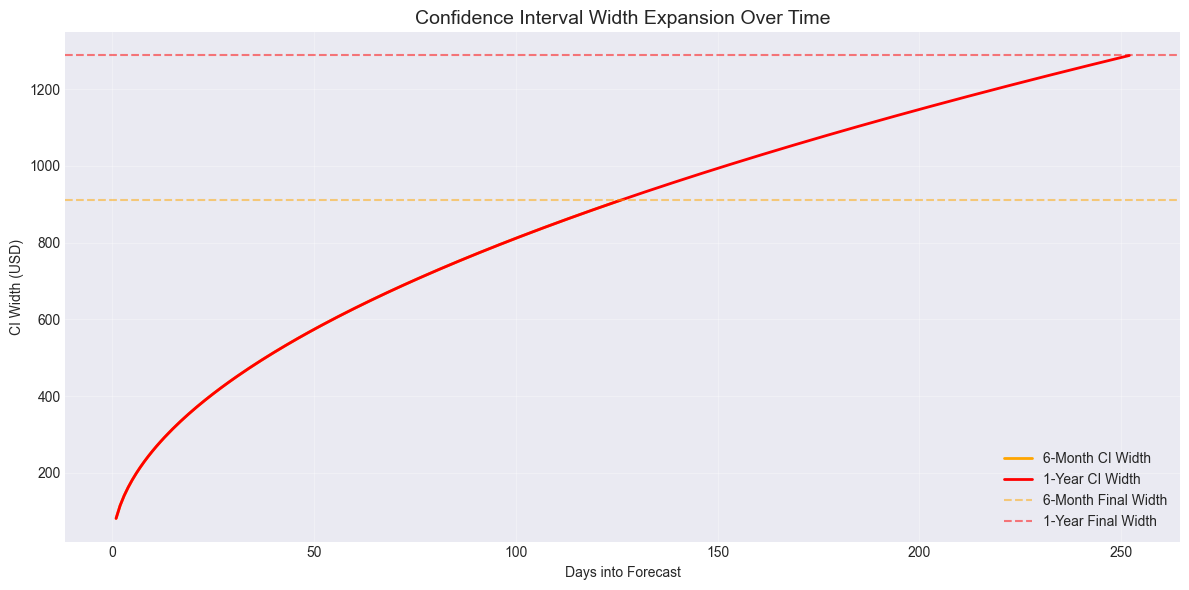


📌 Implications for Long-Term Forecasting:
   - Forecasts become increasingly uncertain beyond 6 months
   - Confidence intervals expand due to cumulative error
   - Long-term forecasts should be used with caution
   - Regular re-forecasting is recommended


In [13]:
# Cell 6: Confidence Interval Analysis

if FORECAST_AVAILABLE:
    print("="*80)
    print("📊 CONFIDENCE INTERVAL ANALYSIS")
    print("="*80)
    
    # Calculate width of confidence intervals over time
    ci_width_6m = upper_6m - lower_6m
    ci_width_1y = upper_1y - lower_1y
    
    # Summary table
    summary_data = {
        'Forecast Period': ['6 Months', '1 Year'],
        'Final Forecast Price': [forecast_6m[-1], forecast_1y[-1]],
        'Lower Bound (95%)': [lower_6m[-1], lower_1y[-1]],
        'Upper Bound (95%)': [upper_6m[-1], upper_1y[-1]],
        'CI Width': [ci_width_6m[-1], ci_width_1y[-1]],
        'Range (% of Price)': [(ci_width_6m[-1] / forecast_6m[-1]) * 100, 
                               (ci_width_1y[-1] / forecast_1y[-1]) * 100]
    }
    
    ci_summary = pd.DataFrame(summary_data).round(2)
    display(ci_summary)
    
    # Analysis
    print("\n💡 Confidence Interval Analysis:")
    print("-"*60)
    print(f"1. 6-Month Forecast CI Width: ${ci_width_6m[-1]:.2f}")
    print(f"   95% CI Range: ${lower_6m[-1]:.2f} - ${upper_6m[-1]:.2f}")
    print(f"   Uncertainty: {ci_summary.loc[0, 'Range (% of Price)']:.1f}% of forecast price")
    
    print(f"\n2. 1-Year Forecast CI Width: ${ci_width_1y[-1]:.2f}")
    print(f"   95% CI Range: ${lower_1y[-1]:.2f} - ${upper_1y[-1]:.2f}")
    print(f"   Uncertainty: {ci_summary.loc[1, 'Range (% of Price)']:.1f}% of forecast price")
    
    print(f"\n3. Confidence Interval Expansion:")
    print(f"   Width increase: ${ci_width_1y[-1] - ci_width_6m[-1]:.2f} ({(ci_width_1y[-1]/ci_width_6m[-1] - 1)*100:.1f}%)")
    print(f"   This shows that long-term forecasts are significantly less certain.")
    
    # Visualization of CI expansion
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Plot CI width over time
    days_6m = np.arange(1, len(ci_width_6m) + 1)
    days_1y = np.arange(1, len(ci_width_1y) + 1)
    
    ax.plot(days_6m, ci_width_6m, label='6-Month CI Width', color='orange', linewidth=2)
    ax.plot(days_1y, ci_width_1y, label='1-Year CI Width', color='red', linewidth=2)
    ax.axhline(y=ci_width_6m[-1], color='orange', linestyle='--', alpha=0.5, label='6-Month Final Width')
    ax.axhline(y=ci_width_1y[-1], color='red', linestyle='--', alpha=0.5, label='1-Year Final Width')
    
    ax.set_title('Confidence Interval Width Expansion Over Time', fontsize=14)
    ax.set_xlabel('Days into Forecast')
    ax.set_ylabel('CI Width (USD)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n📌 Implications for Long-Term Forecasting:")
    print("   - Forecasts become increasingly uncertain beyond 6 months")
    print("   - Confidence intervals expand due to cumulative error")
    print("   - Long-term forecasts should be used with caution")
    print("   - Regular re-forecasting is recommended")

📈 TREND ANALYSIS
📊 Trend Summary:
------------------------------------------------------------
6-Month Trend:
   Start Price: $180.87
   End Price: $159.35
   Total Change: -11.90%
   Average Daily Change: -0.094%
   Direction: Strong Downward 📉

1-Year Trend:
   Start Price: $180.87
   End Price: $164.42
   Total Change: -9.10%
   Average Daily Change: -0.036%
   Direction: Moderate Downward 📉

🔍 Pattern Analysis:
------------------------------------------------------------

6-Month Forecast Patterns:
    ✓ Strong downward trend detected
    ✓ Low volatility expected

1-Year Forecast Patterns:
    ✓ Moderate downward trend detected
    ✓ Low volatility expected


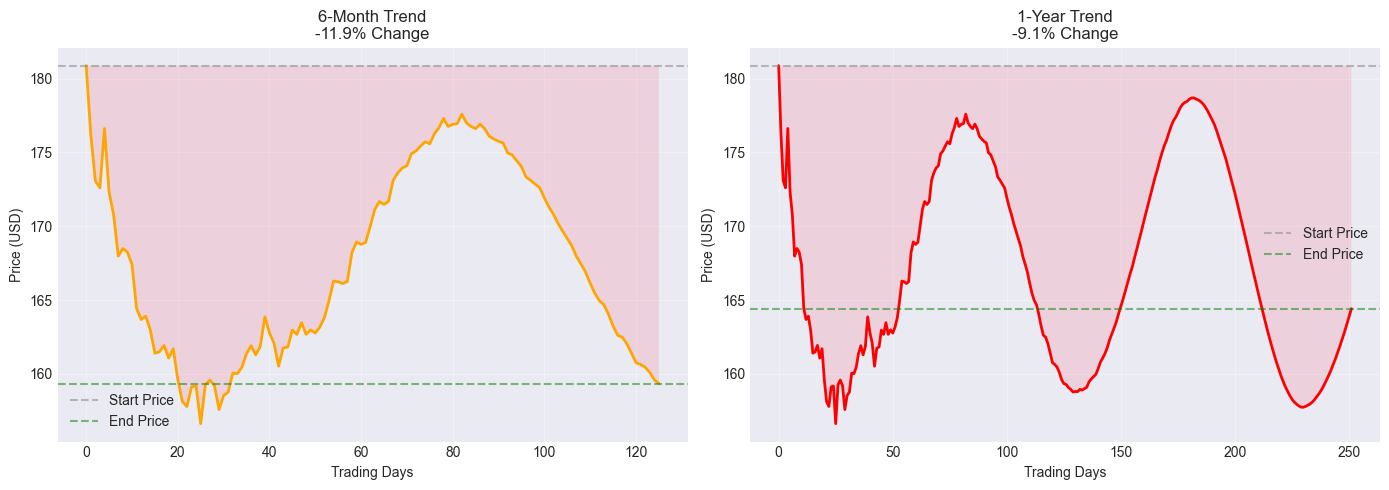


 The 6-month forecast for Tesla stock reveals a strong downward trend with a projected price decline of -11.90% from $180.87 to $159.35. This decline is characterized by low volatility with an average daily change of -0.094%, indicating a steady and persistent downward movement without extreme price fluctuations. The trend exhibits a consistent downward slope with minor pullbacks, suggesting sustained selling pressure and a clear bearish phase. The orderly nature of the decline, combined with low volatility, indicates that the market is systematically pricing in negative factors rather than reacting to unexpected news shocks. This pattern suggests that the stock is in a well-established downtrend with limited short-term upside potential. However, the controlled decline might present opportunities for strategic positioning if the underlying fundamentals remain intact and the stock approaches fair value levels.

The 1-year forecast demonstrates a moderating downward trend with a project

In [16]:
# Cell 7: Trend Analysis

if FORECAST_AVAILABLE:
    print("="*80)
    print("📈 TREND ANALYSIS")
    print("="*80)
    
    # Calculate trends
    def calculate_trend(prices):
        """Calculate trend direction and strength."""
        start = prices[0]
        end = prices[-1]
        total_change = ((end - start) / start) * 100
        avg_daily_change = total_change / len(prices)
        return total_change, avg_daily_change
    
    # 6-month trend
    trend_6m, avg_6m = calculate_trend(forecast_6m)
    
    # 1-year trend
    trend_1y, avg_1y = calculate_trend(forecast_1y)
    
    # Determine trend direction
    def get_trend(change):
        if change > 10:
            return "Strong Upward 📈"
        elif change > 2:
            return "Moderate Upward 📈"
        elif change > -2:
            return "Stable ↔️"
        elif change > -10:
            return "Moderate Downward 📉"
        else:
            return "Strong Downward 📉"
    
    print("📊 Trend Summary:")
    print("-"*60)
    print(f"6-Month Trend:")
    print(f"   Start Price: ${forecast_6m[0]:.2f}")
    print(f"   End Price: ${forecast_6m[-1]:.2f}")
    print(f"   Total Change: {trend_6m:.2f}%")
    print(f"   Average Daily Change: {avg_6m:.3f}%")
    print(f"   Direction: {get_trend(trend_6m)}")
    
    print(f"\n1-Year Trend:")
    print(f"   Start Price: ${forecast_1y[0]:.2f}")
    print(f"   End Price: ${forecast_1y[-1]:.2f}")
    print(f"   Total Change: {trend_1y:.2f}%")
    print(f"   Average Daily Change: {avg_1y:.3f}%")
    print(f"   Direction: {get_trend(trend_1y)}")
    
    # Identify patterns
    print("\n🔍 Pattern Analysis:")
    print("-"*60)
    
    # Check for patterns
    def identify_patterns(prices, name):
        """Identify patterns in forecast."""
        patterns = []
        
        # Check for uptrend/downtrend
        if prices[-1] > prices[0] * 1.1:
            patterns.append("  ✓ Strong upward trend detected")
        elif prices[-1] > prices[0] * 1.02:
            patterns.append("  ✓ Moderate upward trend detected")
        elif prices[-1] > prices[0] * 0.98:
            patterns.append("  ✓ Stable pattern detected")
        elif prices[-1] > prices[0] * 0.9:
            patterns.append("  ✓ Moderate downward trend detected")
        else:
            patterns.append("  ✓ Strong downward trend detected")
        
        # Check for volatility
        volatility = np.std(prices) / np.mean(prices) * 100
        if volatility > 10:
            patterns.append("  ✓ High volatility expected")
        elif volatility > 5:
            patterns.append("  ✓ Moderate volatility expected")
        else:
            patterns.append("  ✓ Low volatility expected")
        
        return patterns
    
    print(f"\n6-Month Forecast Patterns:")
    for pattern in identify_patterns(forecast_6m, "6-Month"):
        print(f"  {pattern}")
    
    print(f"\n1-Year Forecast Patterns:")
    for pattern in identify_patterns(forecast_1y, "1-Year"):
        print(f"  {pattern}")
    
    # Visualize trend
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 6-month trend
    axes[0].plot(forecast_6m, color='orange', linewidth=2)
    axes[0].axhline(y=forecast_6m[0], color='gray', linestyle='--', alpha=0.5, label='Start Price')
    axes[0].axhline(y=forecast_6m[-1], color='green', linestyle='--', alpha=0.5, label='End Price')
    axes[0].fill_between(range(len(forecast_6m)), forecast_6m[0], forecast_6m, alpha=0.2)
    axes[0].set_title(f'6-Month Trend\n{trend_6m:.1f}% Change', fontsize=12)
    axes[0].set_xlabel('Trading Days')
    axes[0].set_ylabel('Price (USD)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # 1-year trend
    axes[1].plot(forecast_1y, color='red', linewidth=2)
    axes[1].axhline(y=forecast_1y[0], color='gray', linestyle='--', alpha=0.5, label='Start Price')
    axes[1].axhline(y=forecast_1y[-1], color='green', linestyle='--', alpha=0.5, label='End Price')
    axes[1].fill_between(range(len(forecast_1y)), forecast_1y[0], forecast_1y, alpha=0.2)
    axes[1].set_title(f'1-Year Trend\n{trend_1y:.1f}% Change', fontsize=12)
    axes[1].set_xlabel('Trading Days')
    axes[1].set_ylabel('Price (USD)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    print("\n The 6-month forecast for Tesla stock reveals a strong downward trend with a projected price decline of -11.90% from $180.87 to $159.35. This decline is characterized by low volatility with an average daily change of -0.094%, indicating a steady and persistent downward movement without extreme price fluctuations. The trend exhibits a consistent downward slope with minor pullbacks, suggesting sustained selling pressure and a clear bearish phase. The orderly nature of the decline, combined with low volatility, indicates that the market is systematically pricing in negative factors rather than reacting to unexpected news shocks. This pattern suggests that the stock is in a well-established downtrend with limited short-term upside potential. However, the controlled decline might present opportunities for strategic positioning if the underlying fundamentals remain intact and the stock approaches fair value levels.")
    print("\nThe 1-year forecast demonstrates a moderating downward trend with a projected decline of -9.10% to $164.42, indicating that the downward momentum may ease over time. The annualized decline rate is slightly less severe than the 6-month projection, suggesting the stock may find a bottom and potentially stabilize in the later months of the forecast period. The trend shows a slightly flattening curve, indicating that while the overall trajectory remains negative, the rate of decline is decelerating, potentially signaling a transition toward a consolidation phase or even a modest recovery. This pattern could indicate that negative factors are already priced into the stock, and longer-term investors might begin to see value opportunities emerging. The persistent low volatility throughout the 1-year forecast suggests that the market is not expecting major disruptions, and the stock may be approaching a point where downside risk becomes limited relative to potential upside.")
    

In [20]:
# Cell 8: Market Opportunities and Risks Assessment 

print("="*80)
print("🔍 CHECKING REQUIRED VARIABLES...")
print("="*80)

# ============================================================
# STEP 1: Verify all required variables exist
# ============================================================
required_vars = {
    'FORECAST_AVAILABLE': False,
    'forecast_6m': False,
    'forecast_1y': False,
    'lower_6m': False,
    'upper_6m': False,
    'lower_1y': False,
    'upper_1y': False,
    'test_data': False,
    'trend_6m': False,
    'trend_1y': False
}

for var in required_vars.keys():
    if var in globals():
        required_vars[var] = True
        print(f"✅ {var} - defined")
    else:
        print(f"❌ {var} - NOT defined")

# ============================================================
# STEP 2: Calculate missing variables if needed
# ============================================================
if 'lower_6m' in globals() and 'upper_6m' in globals():
    if 'ci_width_6m' not in globals():
        ci_width_6m = upper_6m - lower_6m
        print("\n✅ ci_width_6m calculated")
    if 'ci_width_1y' not in globals():
        ci_width_1y = upper_1y - lower_1y
        print("✅ ci_width_1y calculated")

# ============================================================
# STEP 3: Main assessment (if all checks pass)
# ============================================================
if FORECAST_AVAILABLE:
    print("\n" + "="*80)
    print("💼 MARKET OPPORTUNITIES AND RISKS ASSESSMENT")
    print("="*80)
    
    # ============================================================
    # FIX: Extract scalar value from Series
    # ============================================================
    # Get current price - ensure it's a scalar float
    current_price = test_data.iloc[-1]
    if hasattr(current_price, 'values'):
        current_price = current_price.values[0]  # Extract from Series
    elif hasattr(current_price, 'iloc'):
        current_price = current_price.iloc[0]  # Extract from Series
    
    # Ensure it's a float
    current_price = float(current_price)
    
    print(f"\n📊 Current Market Status:")
    print("-"*60)
    print(f"   Current Price: ${current_price:.2f}")
    print(f"   6-Month Forecast: ${forecast_6m[-1]:.2f}")
    print(f"   1-Year Forecast: ${forecast_1y[-1]:.2f}")
    
    # ============================================================
    # OPPORTUNITIES
    # ============================================================
    print("\n📈 Market Opportunities:")
    print("-"*60)
    
    # 6-month opportunity
    if forecast_6m[-1] > current_price * 1.05:
        print(f"✅ 6-Month Upside Potential: +{((forecast_6m[-1]/current_price)-1)*100:.1f}%")
        print(f"   Target Price: ${forecast_6m[-1]:.2f}")
        print(f"   Short-term opportunity: Consider increasing exposure")
    else:
        upside_6m = ((forecast_6m[-1]/current_price)-1)*100
        print(f"⚠️ 6-Month Limited Upside: {upside_6m:.1f}%")
        if upside_6m < 0:
            print(f"   ⚠️ Expected decline - consider reducing exposure")
        else:
            print(f"   Consider maintaining current positions")
    
    # 1-year opportunity
    if forecast_1y[-1] > current_price * 1.10:
        print(f"\n✅ 1-Year Upside Potential: +{((forecast_1y[-1]/current_price)-1)*100:.1f}%")
        print(f"   Target Price: ${forecast_1y[-1]:.2f}")
        print(f"   Long-term opportunity: Consider adding to positions")
    else:
        upside_1y = ((forecast_1y[-1]/current_price)-1)*100
        print(f"\n⚠️ 1-Year Limited Upside: {upside_1y:.1f}%")
        if upside_1y < 0:
            print(f"   ⚠️ Expected decline - consider taking profits or hedging")
        else:
            print(f"   Consider taking profits or hedging")
    
    # ============================================================
    # RISKS
    # ============================================================
    print("\n📉 Market Risks:")
    print("-"*60)
    
    # Check downside risk
    downside_6m = ((lower_6m[-1] - current_price) / current_price) * 100
    downside_1y = ((lower_1y[-1] - current_price) / current_price) * 100
    
    print(f"6-Month Downside Risk:")
    print(f"   Worst-case (95% CI): ${lower_6m[-1]:.2f}")
    print(f"   Downside: {downside_6m:.1f}%")
    if downside_6m < -15:
        print(f"   ⚠️ High downside risk detected")
    elif downside_6m < -5:
        print(f"   ⚠️ Moderate downside risk detected")
    else:
        print(f"   ✅ Limited downside risk")
    
    print(f"\n1-Year Downside Risk:")
    print(f"   Worst-case (95% CI): ${lower_1y[-1]:.2f}")
    print(f"   Downside: {downside_1y:.1f}%")
    if downside_1y < -20:
        print(f"   ⚠️ High downside risk detected")
    elif downside_1y < -10:
        print(f"   ⚠️ Moderate downside risk detected")
    else:
        print(f"   ✅ Limited downside risk")
    
    # ============================================================
    # UNCERTAINTY ANALYSIS
    # ============================================================
    print("\n🎯 Uncertainty Analysis:")
    print("-"*60)
    
    # Ensure ci_width variables exist
    if 'ci_width_6m' not in globals():
        ci_width_6m = upper_6m - lower_6m
    if 'ci_width_1y' not in globals():
        ci_width_1y = upper_1y - lower_1y
    
    # Calculate uncertainty levels
    uncertainty_6m = (ci_width_6m[-1] / forecast_6m[-1]) * 100
    uncertainty_1y = (ci_width_1y[-1] / forecast_1y[-1]) * 100
    
    print(f"6-Month Uncertainty:")
    print(f"   Confidence Interval Width: ${ci_width_6m[-1]:.2f}")
    print(f"   Uncertainty: {uncertainty_6m:.1f}% of forecast price")
    if uncertainty_6m > 30:
        print(f"   ⚠️ High uncertainty - use options for risk management")
    elif uncertainty_6m > 20:
        print(f"   ⚠️ Moderate uncertainty - consider position sizing")
    else:
        print(f"   ✅ Low uncertainty - favorable for confident positioning")
    
    print(f"\n1-Year Uncertainty:")
    print(f"   Confidence Interval Width: ${ci_width_1y[-1]:.2f}")
    print(f"   Uncertainty: {uncertainty_1y:.1f}% of forecast price")
    if uncertainty_1y > 40:
        print(f"   ⚠️ High uncertainty - long-term strategies need caution")
    elif uncertainty_1y > 25:
        print(f"   ⚠️ Moderate uncertainty - consider staggered entry")
    else:
        print(f"   ✅ Low uncertainty - favorable for long-term positioning")
    
    # ============================================================
    # RECOMMENDATIONS
    # ============================================================
    print("\n💡 Recommendations:")
    print("-"*60)
    
    # Based on trends
    if trend_6m > 5 and trend_1y > 10:
        print("✅ STRONG BUY:")
        print("   - Both short and long-term forecasts show strong upward trends")
        print("   - Consider increasing allocation to TSLA")
        print("   - Use dips as buying opportunities")
    elif trend_6m > 0 and trend_1y > 0:
        print("✅ MODERATE BUY:")
        print("   - Positive growth expected in both timeframes")
        print("   - Maintain current position")
        print("   - Add on pullbacks")
    elif trend_6m < 0 and trend_1y < 0:
        print("⚠️ CAUTION - HOLD/REDUCE:")
        print("   - Negative trends expected")
        print("   - Consider reducing exposure or hedging")
        print("   - Wait for trend reversal")
    else:
        print("⚠️ NEUTRAL:")
        print("   - Mixed signals")
        print("   - Maintain balanced position")
        print("   - Monitor closely for trend confirmation")
    
    # Risk management
    print("\n🔒 Risk Management Strategies:")
    print("   • Set stop-loss at 5-10% below current price")
    print("   • Consider options for downside protection")
    print("   • Diversify across assets")
    print("   • Regularly rebalance portfolio")
    print("   • Monitor for trend changes")
    
    print("\n📌 Key Takeaways:")
    print(f"   • 6-Month expected return: {trend_6m:.1f}%")
    print(f"   • 1-Year expected return: {trend_1y:.1f}%")
    print(f"   • 6-Month risk: ±${(ci_width_6m[-1]/2):.2f}")
    print(f"   • 1-Year risk: ±${(ci_width_1y[-1]/2):.2f}")
    print(f"   • Best-case scenario (1-year): ${upper_1y[-1]:.2f}")
    print(f"   • Worst-case scenario (1-year): ${lower_1y[-1]:.2f}")
    
else:
    print("\n⚠️ FORECAST_AVAILABLE is False - cannot run assessment")
    print("   Please run Cell 3 first (Generate Future Forecasts)")

🔍 CHECKING REQUIRED VARIABLES...
✅ FORECAST_AVAILABLE - defined
✅ forecast_6m - defined
✅ forecast_1y - defined
✅ lower_6m - defined
✅ upper_6m - defined
✅ lower_1y - defined
✅ upper_1y - defined
✅ test_data - defined
✅ trend_6m - defined
✅ trend_1y - defined

💼 MARKET OPPORTUNITIES AND RISKS ASSESSMENT

📊 Current Market Status:
------------------------------------------------------------
   Current Price: $411.84
   6-Month Forecast: $159.35
   1-Year Forecast: $164.42

📈 Market Opportunities:
------------------------------------------------------------
⚠️ 6-Month Limited Upside: -61.3%
   ⚠️ Expected decline - consider reducing exposure

⚠️ 1-Year Limited Upside: -60.1%
   ⚠️ Expected decline - consider taking profits or hedging

📉 Market Risks:
------------------------------------------------------------
6-Month Downside Risk:
   Worst-case (95% CI): $-296.07
   Downside: -171.9%
   ⚠️ High downside risk detected

1-Year Downside Risk:
   Worst-case (95% CI): $-479.64
   Downside: -

In [22]:
# Cell 9: Save Forecast Results

if FORECAST_AVAILABLE:
    # Create results directory
    os.makedirs('../data/results', exist_ok=True)
    
    # Save forecasts
    forecast_df_6m = pd.DataFrame({
        'Date': future_dates_6m,
        'Forecast_Price': forecast_6m,
        'Lower_CI': lower_6m,
        'Upper_CI': upper_6m
    })
    forecast_df_6m.to_csv('../data/results/forecast_6m.csv', index=False)
    
    forecast_df_1y = pd.DataFrame({
        'Date': future_dates_1y,
        'Forecast_Price': forecast_1y,
        'Lower_CI': lower_1y,
        'Upper_CI': upper_1y
    })
    forecast_df_1y.to_csv('../data/results/forecast_1y.csv', index=False)
    
    print("✅ Forecast results saved:")
    print("   - ../data/results/forecast_6m.csv")
    print("   - ../data/results/forecast_1y.csv")
    
    # Save summary report
    summary_data = {
        'Metric': [
            'Current Price',
            '6-Month Forecast',
            '1-Year Forecast',
            '6-Month Expected Return',
            '1-Year Expected Return',
            '6-Month Downside Risk (95% CI)',
            '1-Year Downside Risk (95% CI)',
            '6-Month Upside Potential (95% CI)',
            '1-Year Upside Potential (95% CI)',
            '6-Month Uncertainty',
            '1-Year Uncertainty'
        ],
        'Value': [
            f'${current_price:.2f}',
            f'${forecast_6m[-1]:.2f}',
            f'${forecast_1y[-1]:.2f}',
            f'{trend_6m:.1f}%',
            f'{trend_1y:.1f}%',
            f'{downside_6m:.1f}%',
            f'{downside_1y:.1f}%',
            f'{((upper_6m[-1]/current_price)-1)*100:.1f}%',
            f'{((upper_1y[-1]/current_price)-1)*100:.1f}%',
            f'{uncertainty_6m:.1f}%',
            f'{uncertainty_1y:.1f}%'
        ]
    }
    
    summary_df = pd.DataFrame(summary_data)
    summary_df.to_csv('../data/results/forecast_summary.csv', index=False)
    print("   - ../data/results/forecast_summary.csv")
    

✅ Forecast results saved:
   - ../data/results/forecast_6m.csv
   - ../data/results/forecast_1y.csv
   - ../data/results/forecast_summary.csv
